In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [18]:
dfs = dict()
dfs['binary_tree'] = pd.read_excel('dataview/binary-tree.xlsx', sheet_name='InputMode')
dfs['multiple_tree'] = pd.read_excel('dataview/multiple-tree.xlsx', sheet_name='InputMode')
dfs['code'] = pd.read_excel('dataview/code.xlsx', sheet_name='CodeType')
dfs['paper'] = pd.DataFrame({'InputMode': ['Structural', 'Plain Text'], 'mean': [33.9, 32.8]})

dfs['binary_tree']['InputMode'] = dfs['binary_tree']['InputMode'].replace({'edge': 'Edge', 'hierarchy': 'Text Tree'})
dfs['multiple_tree']['InputMode'] = dfs['multiple_tree']['InputMode'].replace({'edge': 'Edge', 'hierarchy': 'Text Tree'})
dfs['code']['CodeType'] = dfs['code']['CodeType'].replace({'c++': 'C++', 'python': 'Python'})
dfs['binary_tree'] = dfs['binary_tree'][::-1]
dfs['multiple_tree'] = dfs['multiple_tree'][::-1]
dfs

{'binary_tree':    InputMode       mean        std  count
 1  Text Tree  34.613994  35.024556    696
 0       Edge  32.223036  34.897431    718,
 'multiple_tree':    InputMode       mean        std  count
 1  Text Tree  44.536471  32.675251    544
 0       Edge  44.605916  32.051437    546,
 'code':   CodeType    mean        std  count
 0      C++  57.875  23.403032     40
 1   Python  53.175  21.737227     40,
 'paper':     InputMode  mean
 0  Structural  33.9
 1  Plain Text  32.8}

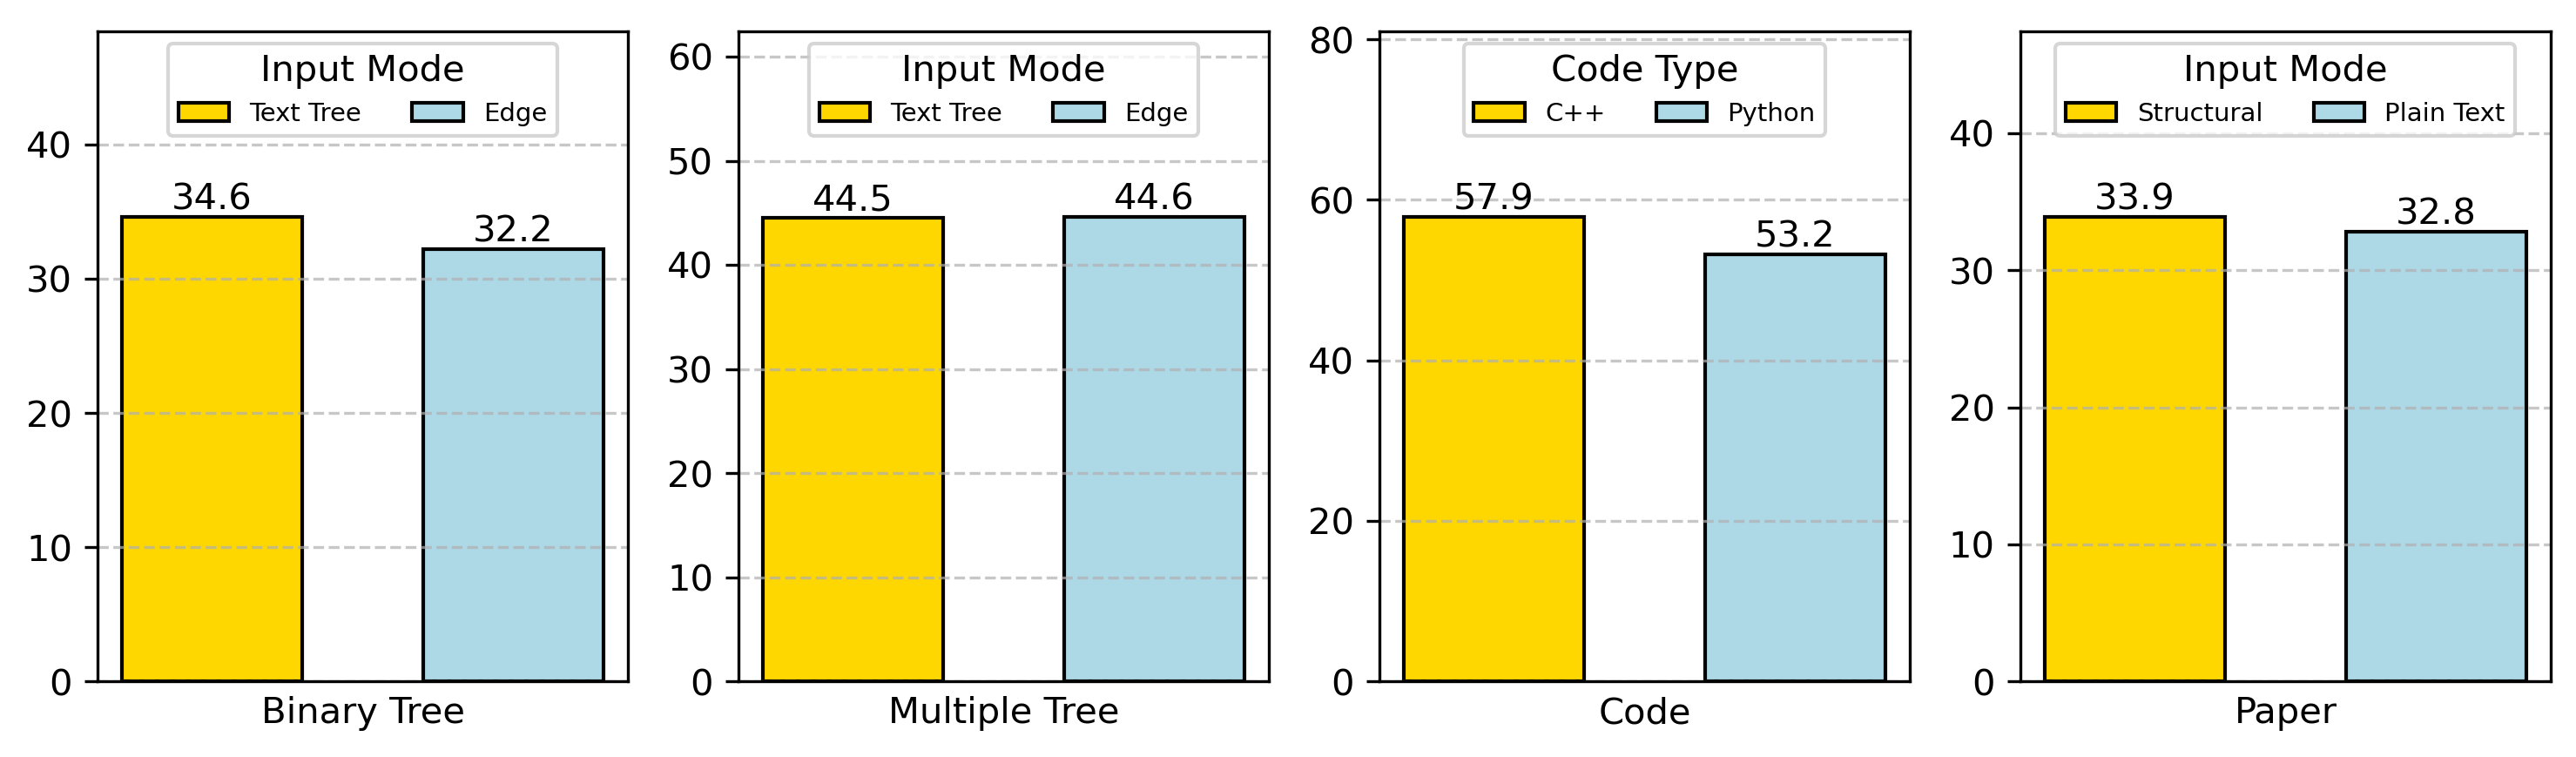

In [19]:

fig, axes = plt.subplots(1, 4, figsize=(10, 3), dpi=300)
colors = ['gold', 'lightblue']

titles = ['Binary Tree', 'Multiple Tree', 'Code', 'Paper']
legend_titles = ['Input Mode', 'Input Mode', 'Code Type', 'Input Mode']

for ax, (key, values), title, legend_title in zip(axes, dfs.items(), titles, legend_titles):
    x = [0, 1]
    bars = ax.bar(
        x, values['mean'], color=colors, label=values[legend_title.replace(' ', '')], 
        width=0.6, edgecolor='black'
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}', 
                ha='center', va='bottom', fontsize=10, color='black')

    ax.set_xticks([])
    ax.set_xlabel(title)
    ax.set_ylim(0, values['mean'].max() * 1.4)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend(title=legend_title, loc='upper center', ncol=2, fontsize=7)

# Adjust layout and display plot
plt.tight_layout()
plt.savefig('../Images/input-mode.pdf')